In [1]:
#! Source-only preflight, immutable experiment provenance, separate study paths
import hashlib
import json
import random
import sys
import time

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from google.colab import drive
from IPython.display import display
from torch.utils.data import DataLoader, Subset
from torchvision import models

drive.mount('/content/drive')

SEED = 6304
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = False

ROOT = Path('/content/drive/MyDrive/pa1-beyond-iid')

PACS_DIR, SHARED_DIR = ROOT / 'data/pacs', ROOT / 'shared'
TASK2, TASK3 = ROOT / 'task2', ROOT / 'task3'
SOURCE_DOMAINS = ['photo', 'art_painting', 'cartoon']
SPLIT_PATH = SHARED_DIR / 'splits/pacs_sketch_seed6304.json'
BASE_PATH = TASK2 / 'configs/base.json'
ERM_CONFIG_PATH = TASK2 / 'configs/source_only.json'
INITIAL_PATH = TASK2 / 'models/resnet18_initial_seed6304.pt'
ERM_BEST_PATH = TASK2 / 'models/source_only_best.pt'
DAN_FILE = TASK2 / 'methods/dan.py'
METHOD_FILE = TASK3 / 'methods/dan_dg.py'
MAIN_CONFIG_PATH = TASK3 / 'configs/dan_dg.json'
MAIN_BEST_PATH = TASK3 / 'models/dan_dg_best.pt'
MAIN_LAST_PATH = TASK3 / 'models/dan_dg_last.pt'
MAIN_SOURCE_PATH = TASK3 / 'results/dan_dg/source_validation.csv'
STUDY_DIR = TASK3 / 'results/dan_dg_controlled'
STUDY_CONFIG_PATH = TASK3 / 'configs/dan_dg_controlled.json'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def sha256(path):
    digest = hashlib.sha256()
    with open(path, 'rb') as stream:
        for block in iter(lambda: stream.read(4 * 1024 * 1024), b''):
            digest.update(block)
    return digest.hexdigest()

required = [PACS_DIR / 'pacs_sources.tar', PACS_DIR / 'source_train.csv',
            PACS_DIR / 'source_val.csv', SHARED_DIR / 'pacs.py',
            SHARED_DIR / 'pacs_training.py', SPLIT_PATH, BASE_PATH,
            ERM_CONFIG_PATH, INITIAL_PATH, ERM_BEST_PATH, DAN_FILE,
            METHOD_FILE, MAIN_CONFIG_PATH, MAIN_BEST_PATH,
            MAIN_LAST_PATH, MAIN_SOURCE_PATH]

missing = [str(path) for path in required if not path.is_file()]

if missing:
    raise FileNotFoundError('Complete Task 2A/2B/2C setup and Task 3A first. Missing: ' + str(missing))

base = json.loads(BASE_PATH.read_text())
erm_run = json.loads(ERM_CONFIG_PATH.read_text())
split = json.loads(SPLIT_PATH.read_text())
main_cfg = json.loads(MAIN_CONFIG_PATH.read_text())
main_last = torch.load(MAIN_LAST_PATH, map_location='cpu', weights_only=True)
main_best = torch.load(MAIN_BEST_PATH, map_location='cpu', weights_only=True)

if (base['seed'] != SEED or split['seed'] != SEED
        or base['source_domains'] != SOURCE_DOMAINS
        or erm_run['base_config_sha256'] != sha256(BASE_PATH)
        or erm_run['source_split_sha256'] != sha256(SPLIT_PATH)
        or erm_run['initial_checkpoint_sha256'] != sha256(INITIAL_PATH)
        or main_cfg['lambda_dg'] != 1.0 or main_cfg['seed'] != SEED
        or main_cfg['target_images_loaded'] is not False
        or main_cfg['initial_checkpoint_sha256'] != sha256(INITIAL_PATH)
        or main_cfg['task2_dan_mmd_module_sha256'] != sha256(DAN_FILE)
        or main_cfg['dan_dg_method_module_sha256'] != sha256(METHOD_FILE)
        or not main_last['finished']
        or main_last['run_config_sha256'] != sha256(MAIN_CONFIG_PATH)
        or main_best['method'] != 'dan_dg'
        or main_best['epoch'] != main_last['best_epoch']
        or main_best['run_config_sha256'] != sha256(MAIN_CONFIG_PATH)):
    raise RuntimeError('Main Task 3A run is unfinished or shared protocol has changed. Inspect before proceeding.')

LABEL_NAMES = base['class_names']

if len(LABEL_NAMES) != 7:
    raise RuntimeError('Expected seven PACS classes')

STUDY_DIR.mkdir(parents=True, exist_ok=True)

print('Task 3A complete; λ=1 checkpoint reused:', MAIN_BEST_PATH)
print('Device:', DEVICE, '| T4 recommended; target images are not accessed.')

Mounted at /content/drive
Task 3A complete; λ=1 checkpoint reused: /content/drive/MyDrive/pa1-beyond-iid/task3/models/dan_dg_best.pt
Device: cuda | T4 recommended; target images are not accessed.


In [2]:
#! Source-only loaders, exact source IDs, unchanged source-pair MMD module
sys.path.insert(0, str(SHARED_DIR))
sys.path.insert(0, str(TASK2 / 'methods'))
sys.path.insert(0, str(TASK3 / 'methods'))

from pacs import make_loaders, set_seed, freeze_bn_running_stats
from pacs_training import (set_epoch_loaders, evaluate_sources,
                           atomic_torch_save, cpu_state_dict)
from dan import multi_kernel_mmd2
from dan_dg import forward_features_logits, dan_dg_objective

LOCAL_ROOT = Path('/content/pacs_task3c_sources_only')

if (LOCAL_ROOT / 'images/sketch').exists():
    raise RuntimeError('Unexpected Sketch images; start a fresh Task 3C runtime')

source_loaders, val_loaders = make_loaders(
    PACS_DIR, LOCAL_ROOT, include_target=False, workers=2
)

train_manifest = pd.read_csv(PACS_DIR / 'source_train.csv')
val_manifest = pd.read_csv(PACS_DIR / 'source_val.csv')

for domain in SOURCE_DOMAINS:
    expected_train = set(split['source_splits'][domain]['train_indices'])
    expected_val = set(split['source_splits'][domain]['val_indices'])
    observed_train = set(train_manifest.loc[train_manifest.domain == domain, 'hf_index'])
    observed_val = set(val_manifest.loc[val_manifest.domain == domain, 'hf_index'])

    if observed_train != expected_train or observed_val != expected_val or expected_train & expected_val:
        raise RuntimeError('Task 2 source split IDs differ for ' + domain)

    loader = source_loaders[domain]

    if loader.batch_size != 8 or not loader.drop_last or not len(loader):
        raise RuntimeError('Expected complete eight-image source batches: ' + domain)

STEPS = max(len(loader) for loader in source_loaders.values())

if STEPS != erm_run['steps_per_source_epoch'] or STEPS != main_cfg['steps_per_epoch']:
    raise RuntimeError('Source epoch length disagrees with Task 2 ERM / Task 3A')

#! A mathematical test, not a substitute for real PACS training.
f = torch.randn(24, 512, requires_grad=True)
z = torch.randn(24, 7, requires_grad=True)
y = torch.arange(24) % 7
small, ce_small, mmd_small, pair_small = dan_dg_objective(f, z, y, lambda_dg=0.1)
large, ce_large, mmd_large, pair_large = dan_dg_objective(f, z, y, lambda_dg=10.0)

if (len(pair_small) != 3 or not torch.allclose(mmd_small, mmd_large, atol=1e-7)
        or not torch.allclose(large-small, 9.9*mmd_small, rtol=1e-5, atol=1e-5)):
    raise RuntimeError('The controlled study changes more than λ or computes MMD inconsistently')

large.backward()

if (f.grad is None or z.grad is None or not torch.isfinite(f.grad).all()
        or not torch.isfinite(z.grad).all()):
    raise RuntimeError('Controlled MMD gradients are invalid')

del f, z, y, small, large, ce_small, ce_large, mmd_small, mmd_large, pair_small, pair_large

print('Source batches: 8 + 8 + 8, updates per epoch:', STEPS)
print('Three-pair λ isolation and finite-gradient checks: PASS')
print('No target loader, no overwritten shared module.')

Source batches: 8 + 8 + 8, updates per epoch: 234
Three-pair λ isolation and finite-gradient checks: PASS
No target loader, no overwritten shared module.


In [3]:
#! Lock all design choices before running controlled experiments
INITIAL_SHA = sha256(INITIAL_PATH)
INITIAL_STATE = torch.load(INITIAL_PATH, map_location='cpu', weights_only=True)

if INITIAL_STATE['seed'] != SEED or INITIAL_STATE['class_names'] != LABEL_NAMES:
    raise RuntimeError('Initial seven-class model does not match Task 2 setup')

BN_REFERENCE = {name: tensor.detach().cpu().clone()
                for name, tensor in INITIAL_STATE['model_state_dict'].items()
                if name.endswith(('running_mean', 'running_var', 'num_batches_tracked'))}

LAMBDA_SETTINGS = [(0.1, '0p1'), (1.0, '1'), (10.0, '10')]

CONTROL_CONFIG = {
    'method': 'dan_dg_controlled', 'seed': SEED,
    'lambda_values': [0.1, 1.0, 10.0],
    'main_lambda': 1.0, 'main_checkpoint_reused': True,
    'main_checkpoint_sha256': sha256(MAIN_BEST_PATH),
    'main_config_sha256': sha256(MAIN_CONFIG_PATH),
    'initial_checkpoint_sha256': INITIAL_SHA,
    'erm_checkpoint_sha256': sha256(ERM_BEST_PATH),
    'base_config_sha256': sha256(BASE_PATH),
    'source_split_sha256': sha256(SPLIT_PATH),
    'train_manifest_sha256': sha256(PACS_DIR / 'source_train.csv'),
    'val_manifest_sha256': sha256(PACS_DIR / 'source_val.csv'),
    'pacs_module_sha256': sha256(SHARED_DIR / 'pacs.py'),
    'training_module_sha256': sha256(SHARED_DIR / 'pacs_training.py'),
    'mmd_module_sha256': sha256(DAN_FILE),
    'dan_dg_module_sha256': sha256(METHOD_FILE),
    'source_domains': SOURCE_DOMAINS,
    'batch_per_source_domain': 8, 'steps_per_epoch': STEPS,
    'learning_rate': base['learning_rate'],
    'weight_decay': base['weight_decay'],
    'max_epochs': base['max_source_epochs'],
    'patience': base['early_stopping_patience'],
    'checkpoint_selection': 'mean source-validation macro-F1',
    'study_selection_rule': 'source validation only; main lambda stays 1',
    'source_diagnostic': 'balanced 64-or-fewer source-validation features per domain; pairwise MMD',
    'precision': 'FP32', 'batchnorm_running_statistics': 'frozen',
    'target_images_loaded': False, 'target_labels_used': False,
    'target_metrics_used_for_selection': False,
    'sketch_final_analysis': 'Task3D only after all decisions fixed'
}

if (CONTROL_CONFIG['learning_rate'] != erm_run['learning_rate']
        or CONTROL_CONFIG['weight_decay'] != erm_run['weight_decay']
        or CONTROL_CONFIG['max_epochs'] != erm_run['max_epochs']
        or CONTROL_CONFIG['patience'] != erm_run['patience']):
    raise RuntimeError('Study training hyperparameters differ from Task 2 / Task 3A')

if STUDY_CONFIG_PATH.is_file():
    if json.loads(STUDY_CONFIG_PATH.read_text()) != CONTROL_CONFIG:
        raise RuntimeError('Existing controlled-study design differs; inspect rather than overwriting')
else:
    STUDY_CONFIG_PATH.write_text(json.dumps(CONTROL_CONFIG, indent=2))

CONTROL_SHA = sha256(STUDY_CONFIG_PATH)

def study_paths(slug):
    folder = STUDY_DIR / f'lambda_{slug}'
    return {
        'dir': folder, 'config': TASK3 / 'configs' / f'dan_dg_lambda_{slug}.json',
        'best': TASK3 / 'models' / f'dan_dg_lambda_{slug}_best.pt',
        'last': TASK3 / 'models' / f'dan_dg_lambda_{slug}_last.pt'
    }

print('Locked study:', STUDY_CONFIG_PATH)

for value, slug in LAMBDA_SETTINGS:
    if value != 1.0:
        print(f'λ={value}:', study_paths(slug)['best'])

print('λ=1 remains unchanged:', MAIN_BEST_PATH)

Locked study: /content/drive/MyDrive/pa1-beyond-iid/task3/configs/dan_dg_controlled.json
λ=0.1: /content/drive/MyDrive/pa1-beyond-iid/task3/models/dan_dg_lambda_0p1_best.pt
λ=10.0: /content/drive/MyDrive/pa1-beyond-iid/task3/models/dan_dg_lambda_10_best.pt
λ=1 remains unchanged: /content/drive/MyDrive/pa1-beyond-iid/task3/models/dan_dg_best.pt


In [4]:
#! One source-only training implementation for both new λ values

def _next_or_cycle(iterator, loader):
    try:
        return next(iterator), iterator
    except StopIteration:
        renewed = iter(loader)
        return next(renewed), renewed


def _run_single_lambda(lambda_dg, slug):
    paths = study_paths(slug)
    paths['dir'].mkdir(parents=True, exist_ok=True)

    run_config = {
        'method': 'dan_dg_controlled', 'seed': SEED, 'lambda_dg': lambda_dg,
        'parent_study_config_sha256': CONTROL_SHA,
        'main_config_sha256': sha256(MAIN_CONFIG_PATH),
        'initial_checkpoint_sha256': INITIAL_SHA,
        'mmd_module_sha256': sha256(DAN_FILE),
        'dan_dg_module_sha256': sha256(METHOD_FILE),
        'source_split_sha256': sha256(SPLIT_PATH),
        'steps_per_epoch': STEPS, 'learning_rate': CONTROL_CONFIG['learning_rate'],
        'weight_decay': CONTROL_CONFIG['weight_decay'],
        'max_epochs': CONTROL_CONFIG['max_epochs'], 'patience': CONTROL_CONFIG['patience'],
        'checkpoint_selection': 'mean source-validation macro-F1',
        'precision': 'FP32', 'target_images_used': False
    }

    if paths['config'].is_file():
        if json.loads(paths['config'].read_text()) != run_config:
            raise RuntimeError('Existing λ config differs; refusing checkpoint overwrite: ' + str(paths['config']))
    else:
        paths['config'].write_text(json.dumps(run_config, indent=2))

    config_sha = sha256(paths['config'])

    #! Reset RNG and create a NEW optimizer/model from Task 2's original initialization.
    set_seed(SEED)

    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, 7)
    model.load_state_dict(INITIAL_STATE['model_state_dict'], strict=True)
    model = model.to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(), lr=run_config['learning_rate'],
                                  weight_decay=run_config['weight_decay'])

    history = []

    best_f1, best_epoch, bad_epochs, start_epoch = -1.0, 0, 0, 1

    finished = False

    if paths['last'].is_file():
        last = torch.load(paths['last'], map_location='cpu', weights_only=True)

        if (last['run_config_sha256'] != config_sha or last['lambda_dg'] != lambda_dg
                or not paths['best'].is_file()):
            raise RuntimeError('Saved λ run cannot be resumed safely: ' + slug)

        model.load_state_dict(last['model_state_dict'], strict=True)
        optimizer.load_state_dict(last['optimizer_state_dict'])
        random.setstate(last['python_rng_state'])
        torch.set_rng_state(last['torch_rng_state'])

        if DEVICE.type == 'cuda' and last.get('cuda_rng_state') is not None:
            torch.cuda.set_rng_state_all(last['cuda_rng_state'])

        history = last['history']
        best_f1, best_epoch, bad_epochs = last['best_f1'], last['best_epoch'], last['bad_epochs']
        start_epoch, finished = last['epoch'] + 1, last['finished']

        if len(history) != last['epoch']:
            raise RuntimeError('Incomplete history in λ=' + str(lambda_dg))

        print(f'λ={lambda_dg}: resumed complete epoch {last["epoch"]}; finished={finished}')
    elif paths['best'].is_file():
        raise RuntimeError('Best checkpoint exists without resumable last state: ' + slug)
    else:
        print(f'λ={lambda_dg}: new model from SAME initial weights (not ERM or DAN-DG trained weights)')

    if not finished:
        for epoch in range(start_epoch, run_config['max_epochs'] + 1):
            started = time.perf_counter()

            model.train()

            freeze_bn_running_stats(model)

            set_epoch_loaders(source_loaders, epoch, SEED)
            source_iters = {domain: iter(source_loaders[domain]) for domain in SOURCE_DOMAINS}

            sums = {'train_total_loss': 0.0, 'train_cls_loss': 0.0,
                    'train_alignment_loss': 0.0, 'mmd_photo_art': 0.0,
                    'mmd_photo_cartoon': 0.0, 'mmd_art_cartoon': 0.0}

            correct = 0

            for step in range(STEPS):
                batches = []
                for domain in SOURCE_DOMAINS:
                    batch, source_iters[domain] = _next_or_cycle(source_iters[domain], source_loaders[domain])
                    batches.append(batch)

                images = torch.cat([batch[0] for batch in batches]).to(DEVICE, non_blocking=True)
                labels = torch.cat([batch[1] for batch in batches]).to(DEVICE, non_blocking=True)

                if images.shape != (24, 3, 224, 224) or labels.shape != (24,):
                    raise RuntimeError(f'Unexpected source batch λ={lambda_dg}, epoch={epoch}, step={step}')

                optimizer.zero_grad(set_to_none=True)
                features, logits = forward_features_logits(model, images)

                loss, cls, penalty, pairs = dan_dg_objective(
                    features, logits, labels, lambda_dg=lambda_dg
                )

                if not torch.isfinite(loss).item():
                    raise FloatingPointError(
                        f'λ={lambda_dg} epoch={epoch} step={step}: '
                        f'non-finite CE={cls.detach().item()}, MMD={penalty.detach().item()}, '
                        f'features_finite={torch.isfinite(features).all().item()}, '
                        f'logits_finite={torch.isfinite(logits).all().item()}'
                    )

                loss.backward()

                #! Infinity threshold checks every gradient but does not clip it.
                torch.nn.utils.clip_grad_norm_(model.parameters(), float('inf'), error_if_nonfinite=True)

                optimizer.step()

                sums['train_total_loss'] += loss.detach().item()
                sums['train_cls_loss'] += cls.detach().item()
                sums['train_alignment_loss'] += penalty.detach().item()

                for key, component in zip(('mmd_photo_art', 'mmd_photo_cartoon', 'mmd_art_cartoon'), pairs):
                    sums[key] += component.detach().item()

                correct += int((logits.detach().argmax(dim=1) == labels).sum().item())

            if any(not torch.isfinite(parameter).all().item() for parameter in model.parameters()):
                raise FloatingPointError(f'Non-finite parameters at λ={lambda_dg}, epoch={epoch}; no checkpoint saved')

            train_metrics = {key: val / STEPS for key, val in sums.items()}
            train_metrics.update({'train_accuracy': correct/(STEPS*24),
                                  'updates': STEPS, 'source_examples_processed': STEPS*24,
                                  'target_examples_processed': 0})

            validation = evaluate_sources(model, val_loaders, DEVICE, num_classes=7)
            score = validation['mean_macro_f1']

            if not np.isfinite(score):
                raise FloatingPointError(f'Non-finite source-validation score λ={lambda_dg}, epoch={epoch}')

            improved = score > best_f1 + 1e-8

            if improved:
                best_f1, best_epoch, bad_epochs = score, epoch, 0

                atomic_torch_save({
                    'method': 'dan_dg_controlled', 'seed': SEED, 'lambda_dg': lambda_dg,
                    'epoch': epoch, 'best_source_val_mean_macro_f1': best_f1,
                    'source_validation': validation, 'run_config_sha256': config_sha,
                    'initial_checkpoint_sha256': INITIAL_SHA,
                    'class_names': LABEL_NAMES, 'model_state_dict': cpu_state_dict(model),
                }, paths['best'])
            else:
                bad_epochs += 1

            row = {
                'epoch': epoch, 'lambda_dg': lambda_dg, **train_metrics,
                'mean_source_val_accuracy': validation['mean_accuracy'],
                'mean_source_val_macro_f1': validation['mean_macro_f1'],
                'worst_source_val_accuracy': validation['worst_source_accuracy'],
                'worst_source_val_macro_f1': validation['worst_source_macro_f1'],
                'elapsed_seconds': time.perf_counter()-started
            }

            for domain in SOURCE_DOMAINS:
                row[f'val_{domain}_accuracy'] = validation[domain]['accuracy']
                row[f'val_{domain}_macro_f1'] = validation[domain]['macro_f1']
                row[f'val_{domain}_loss'] = validation[domain]['loss']

            history.append(row)
            finished = bad_epochs >= run_config['patience'] or epoch == run_config['max_epochs']

            atomic_torch_save({
                'method': 'dan_dg_controlled', 'seed': SEED, 'lambda_dg': lambda_dg,
                'epoch': epoch, 'finished': finished,
                'model_state_dict': cpu_state_dict(model),
                'optimizer_state_dict': optimizer.state_dict(),
                'history': history, 'best_epoch': best_epoch, 'best_f1': best_f1,
                'bad_epochs': bad_epochs, 'run_config_sha256': config_sha,
                'python_rng_state': random.getstate(),
                'torch_rng_state': torch.get_rng_state(),
                'cuda_rng_state': torch.cuda.get_rng_state_all() if DEVICE.type == 'cuda' else None,
            }, paths['last'])

            pd.DataFrame(history).to_csv(paths['dir'] / 'history.csv', index=False)

            print(f'λ={lambda_dg:g} epoch={epoch:02d} | CE={train_metrics["train_cls_loss"]:.4f} '
                  f'| pair MMD²={train_metrics["train_alignment_loss"]:.4f} '
                  f'| source F1={score:.4f}, best={best_f1:.4f} at {best_epoch} '
                  f'| patience={bad_epochs}/{run_config["patience"]} '
                  f'| {row["elapsed_seconds"]:.1f}s')
            if finished:
                break

    if not finished or not paths['best'].is_file():
        raise RuntimeError(f'λ={lambda_dg}: finish training before analysis')

    best = torch.load(paths['best'], map_location='cpu', weights_only=True)
    last = torch.load(paths['last'], map_location='cpu', weights_only=True)

    if (best['run_config_sha256'] != config_sha or last['run_config_sha256'] != config_sha
            or best['lambda_dg'] != lambda_dg or last['lambda_dg'] != lambda_dg
            or best['epoch'] != last['best_epoch'] or not last['finished']
            or len(last['history']) != last['epoch']):
        raise RuntimeError('Selected checkpoint and last completed epoch disagree at λ=' + str(lambda_dg))

    #! Evaluate the exact best source-only checkpoint, rather than the final epoch.
    model.load_state_dict(best['model_state_dict'], strict=True)
    metrics = evaluate_sources(model, val_loaders, DEVICE, num_classes=7)

    if not np.isclose(metrics['mean_macro_f1'], best['best_source_val_mean_macro_f1'], atol=1e-7):
        raise RuntimeError('Best checkpoint validation does not reproduce: λ=' + str(lambda_dg))

    table = pd.DataFrame(
        [{'domain': domain, **metrics[domain]} for domain in SOURCE_DOMAINS] +
        [{'domain': 'mean', 'accuracy': metrics['mean_accuracy'],
          'macro_f1': metrics['mean_macro_f1']},
         {'domain': 'worst', 'accuracy': metrics['worst_source_accuracy'],
          'macro_f1': metrics['worst_source_macro_f1']}]
    )

    table.to_csv(paths['dir'] / 'source_validation.csv', index=False)
    current = model.state_dict()

    changed_bn = [key for key, original in BN_REFERENCE.items()
                  if not torch.equal(current[key].detach().cpu(), original)]
    if changed_bn:
        raise RuntimeError('Frozen BatchNorm buffers changed: ' + str(changed_bn[:5]))

    (paths['dir'] / 'summary.json').write_text(json.dumps({
        'method': 'dan_dg_controlled', 'lambda_dg': lambda_dg,
        'checkpoint_path': str(paths['best']), 'checkpoint_sha256': sha256(paths['best']),
        'best_epoch': best['epoch'], 'source_validation': metrics,
        'initial_checkpoint_sha256': INITIAL_SHA,
        'target_evaluation': 'DEFERRED_TO_TASK3D'
    }, indent=2))

    (paths['dir'] / 'batchnorm_audit.json').write_text(json.dumps({
        'running_buffers_equal_to_initial': True,
        'buffer_count': len(BN_REFERENCE), 'affine_trainable': all(
            layer.weight.requires_grad and layer.bias.requires_grad
            for layer in model.modules() if isinstance(layer, nn.modules.batchnorm._BatchNorm)
        )
    }, indent=2))

    print(f'λ={lambda_dg}: complete; best epoch={best["epoch"]}; source F1={metrics["mean_macro_f1"]:.4f}')

    del model, optimizer

    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()
    return metrics

In [5]:
#! First independent controlled run: weak source-domain alignment
metrics_0p1 = _run_single_lambda(0.1, '0p1')

print('λ=0.1 training and source-selected evaluation complete.')

λ=0.1: new model from SAME initial weights (not ERM or DAN-DG trained weights)
λ=0.1 epoch=01 | CE=0.4380 | pair MMD²=0.5771 | source F1=0.9063, best=0.9063 at 1 | patience=0/5 | 35.3s
λ=0.1 epoch=02 | CE=0.1996 | pair MMD²=0.5116 | source F1=0.9257, best=0.9257 at 2 | patience=0/5 | 33.0s
λ=0.1 epoch=03 | CE=0.1480 | pair MMD²=0.4919 | source F1=0.9397, best=0.9397 at 3 | patience=0/5 | 35.4s
λ=0.1 epoch=04 | CE=0.0864 | pair MMD²=0.4873 | source F1=0.9374, best=0.9397 at 3 | patience=1/5 | 36.2s
λ=0.1 epoch=05 | CE=0.0575 | pair MMD²=0.4832 | source F1=0.9450, best=0.9450 at 5 | patience=0/5 | 34.6s
λ=0.1 epoch=06 | CE=0.0596 | pair MMD²=0.4740 | source F1=0.9443, best=0.9450 at 5 | patience=1/5 | 36.7s
λ=0.1 epoch=07 | CE=0.0442 | pair MMD²=0.4832 | source F1=0.9419, best=0.9450 at 5 | patience=2/5 | 34.5s
λ=0.1 epoch=08 | CE=0.0424 | pair MMD²=0.4721 | source F1=0.9398, best=0.9450 at 5 | patience=3/5 | 36.9s
λ=0.1 epoch=09 | CE=0.0421 | pair MMD²=0.4760 | source F1=0.9325, best=0.

In [6]:
#! Second independent controlled run: strong source-domain alignment
metrics_10 = _run_single_lambda(10.0, '10')

print('λ=10 training and source-selected evaluation complete.')

λ=10.0: new model from SAME initial weights (not ERM or DAN-DG trained weights)
λ=10 epoch=01 | CE=1.9476 | pair MMD²=0.5713 | source F1=0.0361, best=0.0361 at 1 | patience=0/5 | 34.7s
λ=10 epoch=02 | CE=1.9500 | pair MMD²=0.5563 | source F1=0.0507, best=0.0507 at 2 | patience=0/5 | 35.2s
λ=10 epoch=03 | CE=1.9638 | pair MMD²=0.5351 | source F1=0.0507, best=0.0507 at 2 | patience=1/5 | 34.6s
λ=10 epoch=04 | CE=1.9375 | pair MMD²=0.5566 | source F1=0.0507, best=0.0507 at 2 | patience=2/5 | 33.6s
λ=10 epoch=05 | CE=1.9292 | pair MMD²=0.5307 | source F1=0.0507, best=0.0507 at 2 | patience=3/5 | 34.8s
λ=10 epoch=06 | CE=1.9274 | pair MMD²=0.5125 | source F1=0.0507, best=0.0507 at 2 | patience=4/5 | 33.7s
λ=10 epoch=07 | CE=1.9222 | pair MMD²=0.4655 | source F1=0.0507, best=0.0507 at 2 | patience=5/5 | 35.7s
λ=10.0: complete; best epoch=2; source F1=0.0507
λ=10 training and source-selected evaluation complete.


In [7]:
#! Read main Task 3A source result, then compute held-out source MMD for all λ
main_source = pd.read_csv(MAIN_SOURCE_PATH)

if set(main_source['domain']) != set(SOURCE_DOMAINS + ['mean', 'worst']):
    raise RuntimeError('Main Task 3A source-validation rows are incomplete')
main_mean_f1 = float(main_source.loc[main_source.domain == 'mean', 'macro_f1'].iloc[0])

if not np.isclose(main_mean_f1, main_best['best_source_val_mean_macro_f1'], atol=1e-7):
    raise RuntimeError('Main λ=1 source-validation CSV disagrees with selected checkpoint')

#! Freeze the image sample and its order independently of every model.
sample_size = min(64, *(len(val_loaders[domain].dataset) for domain in SOURCE_DOMAINS))

if sample_size < 8:
    raise RuntimeError('Insufficient held-out source images for diagnostic')

indices = {}

for number, domain in enumerate(SOURCE_DOMAINS):
    chooser = np.random.default_rng(SEED + number)
    indices[domain] = sorted(chooser.choice(len(val_loaders[domain].dataset),
                                           size=sample_size, replace=False).tolist())

(STUDY_DIR / 'source_diagnostic_sample.json').write_text(json.dumps({
    'seed': SEED, 'samples_per_domain': sample_size,
    'indices_in_source_validation_dataset': indices,
    'source_only': True
}, indent=2))

def heldout_source_pair_mmd(model):
    model.eval()
    feature_groups = []

    with torch.inference_mode():
        for domain in SOURCE_DOMAINS:
            ds = Subset(val_loaders[domain].dataset, indices[domain])
            loader = DataLoader(ds, batch_size=32, shuffle=False, num_workers=2)

            chunks = []

            for images, labels in loader:
                feats, logits = forward_features_logits(model, images.to(DEVICE))
                chunks.append(feats.float())

            feature_groups.append(torch.cat(chunks, dim=0))

        pair_mmd = [float(multi_kernel_mmd2(feature_groups[i], feature_groups[j]).item())
                    for i, j in [(0, 1), (0, 2), (1, 2)]]

    return {'heldout_source_pair_mmd2': float(np.mean(pair_mmd)),
            'heldout_photo_art_mmd2': pair_mmd[0],
            'heldout_photo_cartoon_mmd2': pair_mmd[1],
            'heldout_art_cartoon_mmd2': pair_mmd[2]}

source_diagnostics = {}

for value, slug in LAMBDA_SETTINGS:
    path = MAIN_BEST_PATH if value == 1.0 else study_paths(slug)['best']
    checkpoint = torch.load(path, map_location='cpu', weights_only=True)

    if checkpoint['initial_checkpoint_sha256'] != INITIAL_SHA:
        raise RuntimeError('Initialization mismatch in diagnostic checkpoint: ' + str(path))

    net = models.resnet18(weights=None)
    net.fc = nn.Linear(net.fc.in_features, 7)
    net.load_state_dict(checkpoint['model_state_dict'], strict=True)
    net = net.to(DEVICE)
    source_diagnostics[slug] = heldout_source_pair_mmd(net)

    del net

    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

print('Read-only λ=1 main checkpoint:', MAIN_BEST_PATH)
print('Fixed source diagnostic sample size/domain:', sample_size)

display(pd.DataFrame([{'lambda_dg': v, **source_diagnostics[s]}
                      for v, s in LAMBDA_SETTINGS]).round(5))

Read-only λ=1 main checkpoint: /content/drive/MyDrive/pa1-beyond-iid/task3/models/dan_dg_best.pt
Fixed source diagnostic sample size/domain: 64


,lambda_dg,heldout_source_pair_mmd2,heldout_photo_art_mmd2,heldout_photo_cartoon_mmd2,heldout_art_cartoon_mmd2
0,0.1,0.09450,0.10655,0.11122,0.06573
1,1.0,0.14223,0.17918,0.07824,0.16927
2,10.0,0.08004,0.05955,0.11097,0.06961


,lambda_dg,best_epoch,mean_source_accuracy,mean_source_macro_f1,worst_source_accuracy,worst_source_macro_f1,checkpoint_path,checkpoint_sha256,reuse_main_task3a,heldout_source_pair_mmd2,heldout_photo_art_mmd2,heldout_photo_cartoon_mmd2,heldout_art_cartoon_mmd2,photo_accuracy,photo_macro_f1,art_painting_accuracy,art_painting_macro_f1,cartoon_accuracy,cartoon_macro_f1
0,0.1,10,0.96029,0.95851,0.94146,0.94047,/content/drive/MyDrive/pa1-beyond-iid/task3/mo...,b371b8f62a87a042ab72d4738800d6490cb4117fb5fc52...,False,0.09450,0.10655,0.11122,0.06573,0.98204,0.97947,0.94146,0.94047,0.95736,0.95558
1,1.0,3,0.21657,0.05067,0.17271,0.04208,/content/drive/MyDrive/pa1-beyond-iid/task3/mo...,b2a4bd9a00a875083f206d0a8b10143f27ec816d3f441e...,True,0.14223,0.17918,0.07824,0.16927,0.25749,0.05850,0.21951,0.05143,0.17271,0.04208
2,10.0,2,0.21657,0.05067,0.17271,0.04208,/content/drive/MyDrive/pa1-beyond-iid/task3/mo...,18fcda48f7c5c66ac8065ccc7ebf5b82547883d63de7c7...,False,0.08004,0.05955,0.11097,0.06961,0.25749,0.05850,0.21951,0.05143,0.17271,0.04208


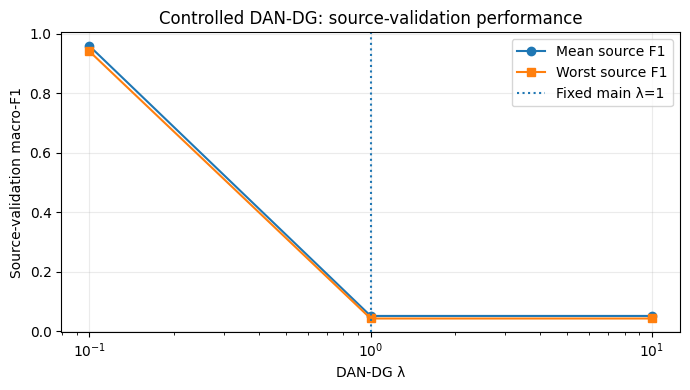

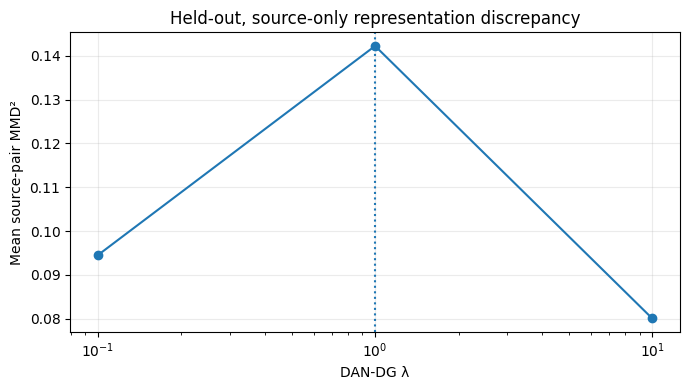

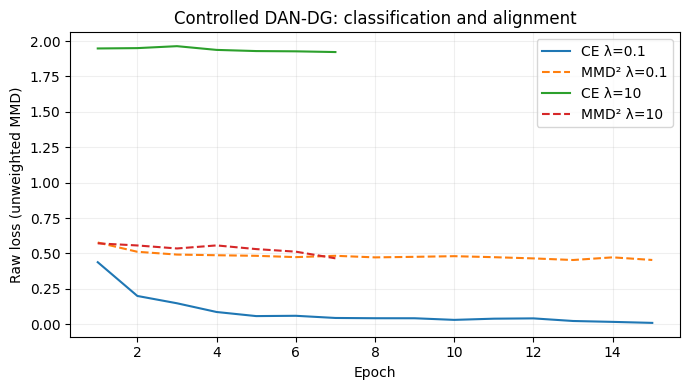

Source-only table and figures saved: /content/drive/MyDrive/pa1-beyond-iid/task3/results/dan_dg_controlled


In [8]:
#! Compact source-only controlled-study evidence; no target performance
rows = []

for value, slug in LAMBDA_SETTINGS:
    if value == 1.0:
        table = main_source
        checkpoint = main_best
        checkpoint_path = MAIN_BEST_PATH
    else:
        table = pd.read_csv(study_paths(slug)['dir'] / 'source_validation.csv')
        checkpoint_path = study_paths(slug)['best']
        checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=True)

    def entry(domain, column):
        return float(table.loc[table.domain == domain, column].iloc[0])

    row = {
        'lambda_dg': value, 'best_epoch': int(checkpoint['epoch']),
        'mean_source_accuracy': entry('mean', 'accuracy'),
        'mean_source_macro_f1': entry('mean', 'macro_f1'),
        'worst_source_accuracy': entry('worst', 'accuracy'),
        'worst_source_macro_f1': entry('worst', 'macro_f1'),
        'checkpoint_path': str(checkpoint_path),
        'checkpoint_sha256': sha256(checkpoint_path),
        'reuse_main_task3a': value == 1.0,
        **source_diagnostics[slug]
    }

    for domain in SOURCE_DOMAINS:
        row[f'{domain}_accuracy'] = entry(domain, 'accuracy')
        row[f'{domain}_macro_f1'] = entry(domain, 'macro_f1')
    rows.append(row)

summary = pd.DataFrame(rows).sort_values('lambda_dg').reset_index(drop=True)
summary.to_csv(STUDY_DIR / 'controlled_source_table.csv', index=False)

(STUDY_DIR / 'controlled_source_summary.json').write_text(json.dumps({
    'study_config_sha256': CONTROL_SHA,
    'design_fixed_lambda': [0.1, 1.0, 10.0],
    'main_comparison_lambda_unchanged': 1.0,
    'target_evaluation': 'DEFERRED_TO_TASK3D',
    'records': rows
}, indent=2))

display(summary.round(5))

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(summary['lambda_dg'], summary['mean_source_macro_f1'], marker='o', label='Mean source F1')
ax.plot(summary['lambda_dg'], summary['worst_source_macro_f1'], marker='s', label='Worst source F1')
ax.axvline(1.0, linestyle=':', label='Fixed main λ=1')
ax.set(xscale='log', xlabel='DAN-DG λ', ylabel='Source-validation macro-F1',
       title='Controlled DAN-DG: source-validation performance')
ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()
fig.savefig(STUDY_DIR / 'controlled_source_f1.png', dpi=220)

plt.show()

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(summary['lambda_dg'], summary['heldout_source_pair_mmd2'], marker='o')
ax.axvline(1.0, linestyle=':')
ax.set(xscale='log', xlabel='DAN-DG λ', ylabel='Mean source-pair MMD²',
       title='Held-out, source-only representation discrepancy')
ax.grid(alpha=0.25)

fig.tight_layout()
fig.savefig(STUDY_DIR / 'controlled_heldout_mmd.png', dpi=220)

plt.show()

fig, ax = plt.subplots(figsize=(7, 4))

for value, slug in [(0.1, '0p1'), (10.0, '10')]:
    h = pd.read_csv(study_paths(slug)['dir'] / 'history.csv')
    ax.plot(h['epoch'], h['train_cls_loss'], label=f'CE λ={value:g}')
    ax.plot(h['epoch'], h['train_alignment_loss'], linestyle='--', label=f'MMD² λ={value:g}')

ax.set(xlabel='Epoch', ylabel='Raw loss (unweighted MMD)',
       title='Controlled DAN-DG: classification and alignment')
ax.grid(alpha=0.2)
ax.legend()

fig.tight_layout()
fig.savefig(STUDY_DIR / 'controlled_train_losses.png', dpi=220)

plt.show()

print('Source-only table and figures saved:', STUDY_DIR)

In [9]:
#! Verify all three λ settings without touching previous checkpoints
required_final = [STUDY_CONFIG_PATH, STUDY_DIR / 'source_diagnostic_sample.json',
                  STUDY_DIR / 'controlled_source_table.csv',
                  STUDY_DIR / 'controlled_source_summary.json',
                  STUDY_DIR / 'controlled_source_f1.png',
                  STUDY_DIR / 'controlled_heldout_mmd.png',
                  STUDY_DIR / 'controlled_train_losses.png']

for value, slug in [(0.1, '0p1'), (10.0, '10')]:
    paths = study_paths(slug)
    required_final.extend([paths['config'], paths['best'], paths['last'],
                           paths['dir'] / 'history.csv', paths['dir'] / 'source_validation.csv',
                           paths['dir'] / 'summary.json', paths['dir'] / 'batchnorm_audit.json'])

missing = [str(path) for path in required_final if not path.is_file()]

if missing:
    raise FileNotFoundError('Missing controlled-study files: ' + str(missing))

if sha256(MAIN_BEST_PATH) != CONTROL_CONFIG['main_checkpoint_sha256']:
    raise RuntimeError('Main Task 3A λ=1 checkpoint changed after study configuration was frozen')

if sha256(MAIN_CONFIG_PATH) != CONTROL_CONFIG['main_config_sha256']:
    raise RuntimeError('Main Task 3A experiment configuration changed')

if sha256(INITIAL_PATH) != INITIAL_SHA or sha256(DAN_FILE) != CONTROL_CONFIG['mmd_module_sha256']:
    raise RuntimeError('Initialization or original MMD implementation changed')

for value, slug in [(0.1, '0p1'), (10.0, '10')]:
    paths = study_paths(slug)

    best = torch.load(paths['best'], map_location='cpu', weights_only=True)
    last = torch.load(paths['last'], map_location='cpu', weights_only=True)

    hist = pd.read_csv(paths['dir'] / 'history.csv')
    val = pd.read_csv(paths['dir'] / 'source_validation.csv')

    audit = json.loads((paths['dir'] / 'batchnorm_audit.json').read_text())

    if (not last['finished'] or best['epoch'] != last['best_epoch']
            or last['lambda_dg'] != value or best['lambda_dg'] != value
            or best['run_config_sha256'] != sha256(paths['config'])
            or last['run_config_sha256'] != sha256(paths['config'])
            or len(hist) != last['epoch']
            or not audit['running_buffers_equal_to_initial']
            or not audit['affine_trainable']
            or not np.isclose(best['best_source_val_mean_macro_f1'],
                              val.loc[val.domain == 'mean', 'macro_f1'].iloc[0], atol=1e-7)):
        raise RuntimeError(f'Controlled-run checkpoint/history/BN mismatch at λ={value}')

final_table = pd.read_csv(STUDY_DIR / 'controlled_source_table.csv')

if (len(final_table) != 3 or final_table['lambda_dg'].tolist() != [0.1, 1.0, 10.0]
        or not final_table['heldout_source_pair_mmd2'].notna().all()):
    raise RuntimeError('Controlled-study table is incomplete')

print('TASK 3C COMPLETE — controlled DAN-DG λ study')
print('Verified saved files:', len(required_final))
print('Main λ=1 checkpoint unchanged; λ=0.1/10 source-only experiments complete.')
print('Sketch not loaded; target analysis belongs ONLY in Task 3D.')

TASK 3C COMPLETE — controlled DAN-DG λ study
Verified saved files: 21
Main λ=1 checkpoint unchanged; λ=0.1/10 source-only experiments complete.
Sketch not loaded; target analysis belongs ONLY in Task 3D.
